# Lecture 02: Introduction to deep learning

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.1-1.4 (Foundations and function approximation), §1.5-1.9 (Optimization, depth, and regularization), §1.10-1.11 (Generalization, sequence models)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# MLPs vs LSTMs vs Transformers on Economic Time Series: Edgeworth Cycles

This is the main day 1 sequence-model notebook. It walks through three architectures on the same task to make the **memory ladder** concrete:

1. **MLP** is memoryless: it sees a single observation at a time. Each prediction is independent.
2. **LSTM** carries a recurrent hidden state forward, with gates that protect long-range information.
3. **Transformer** has no recurrence at all: every position attends to every other in parallel via self-attention.

We use the same simple synthetic Edgeworth-cycle dataset throughout (sudden gasoline-price jumps followed by gradual undercutting, the asymmetric sawtooth pattern documented for retail fuel markets). The series is small enough that everything trains on a CPU in under a minute total.

What to look for:

1. The MLP collapses near the cycle mean: with one observation it cannot tell where it is in the period.
2. The LSTM tracks the sawtooth almost perfectly: a recurrent hidden state encodes phase.
3. The Transformer beats the MLP by an order of magnitude and is competitive with the LSTM, but on this small, highly periodic, low-data problem the LSTM's recurrent inductive bias is hard to beat. Transformers shine when context is long, data is plentiful, and parallelism matters.

_Pedagogical note: this is the historical evolution MLP → LSTM (1997) → Transformer (2017). The point of the comparison is not to crown a winner on a 1000-point toy series, but to make architectural inductive biases visible._

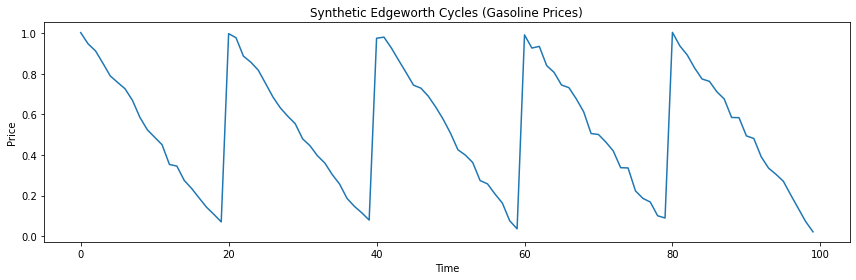

In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13
torch.set_num_threads(4)

# 1. Generate Synthetic Edgeworth Cycle Data
def generate_sawtooth(n_points, period=20, jump=1.0, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n_points)
    cycle = (t % period) / period
    prices = -jump * cycle + jump
    prices += rng.normal(0, 0.02, n_points)
    return prices.astype(np.float32)

n_points = 1000
data = generate_sawtooth(n_points)

plt.figure(figsize=(12, 4))
plt.plot(data[:100])
plt.title('Synthetic Edgeworth Cycles (Gasoline Prices)')
plt.xlabel('Time'); plt.ylabel('Price')
plt.tight_layout(); plt.show()

## 2. Data Preparation

We want to predict $x_{t+1}$ given a window $[x_{t-W+1},\dots,x_t]$ of length $W=10$. The MLP only ever uses the last entry of the window; the LSTM consumes the window recurrently; the Transformer attends to all positions in parallel. Same data for all three models, so any difference is purely architectural.

In [2]:
def create_dataset(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_dataset(data, window_size)

split = 800
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.from_numpy(X_train).unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)
X_test_t  = torch.from_numpy(X_test ).unsqueeze(-1)
y_test_t  = torch.from_numpy(y_test ).unsqueeze(-1)

print('X_train_t shape:', tuple(X_train_t.shape), '(batch, time, features)')
print('y_train_t shape:', tuple(y_train_t.shape))

X_train_t shape: (800, 10, 1) (batch, time, features)
y_train_t shape: (800, 1)


## 3. Define the three models

**MLP** uses only the most recent observation, deliberately.  This is the no-memory baseline.

**LSTM** consumes the window recurrently and reads off the last hidden state.

**Transformer** is a tiny encoder block: input projection $\mathbb{R}\!\to\!\mathbb{R}^{d}$ with $d=16$, learned positional embeddings, two encoder layers with 4 attention heads and a 32-unit feed-forward, then a per-position linear head whose last position is the prediction.  We deliberately keep the parameter count comparable to the LSTM (~4.7k vs 4.5k) so the comparison is honest.

**Parameter counts.** The script (§1.10, p. 52) quotes the TinyTransformer at ≈ 4.7 k parameters; the loop below prints the actual counts so the agreement is explicit.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def forward(self, x):
        # Deliberately use only the most recent observation.
        return self.net(x[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm   = nn.LSTM(input_size=1, hidden_size=32, num_layers=1, batch_first=True)
        self.linear = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])  # last time step

class TinyTransformer(nn.Module):
    def __init__(self, T=10, d_model=16, nhead=4, num_layers=2, dim_ff=32):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_emb    = nn.Parameter(torch.randn(T, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, norm_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.head    = nn.Linear(d_model, 1)
    def forward(self, x):
        h = self.input_proj(x) + self.pos_emb           # (B, T, d)
        z = self.encoder(h)                              # full attention over the window
        return self.head(z[:, -1, :])                    # predict from the last position

def n_params(m):
    return sum(p.numel() for p in m.parameters())

for cls in (MLP, LSTMModel, TinyTransformer):
    print(f'{cls.__name__:<18} {n_params(cls()):>6} parameters')

MLP                    97 parameters
LSTMModel            4513 parameters
TinyTransformer      4657 parameters


/home/simon/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 4. Training

We use Adam everywhere. The MLP and LSTM converge quickly (200 epochs is plenty); the Transformer is trained longer (1000 epochs) with a cosine learning-rate schedule, since it lacks the LSTM's strong recurrent prior and benefits from more careful optimization. Total wall-clock on a laptop CPU is well under a minute.

In [4]:
def train(model, X, y, epochs=200, lr=1e-2, cosine=False):
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine else None
    crit  = nn.MSELoss()
    losses = []
    t0 = time.time()
    for _ in range(epochs):
        opt.zero_grad()
        loss = crit(model(X), y)
        loss.backward()
        opt.step()
        if sched is not None:
            sched.step()
        losses.append(loss.item())
    return model, losses, time.time() - t0

torch.manual_seed(0)
mlp,  loss_mlp,  t_mlp  = train(MLP(),                                          X_train_t, y_train_t, epochs=200, lr=1e-2)
torch.manual_seed(0)
lstm, loss_lstm, t_lstm = train(LSTMModel(),                                    X_train_t, y_train_t, epochs=200, lr=1e-2)
torch.manual_seed(0)
tfr,  loss_tfr,  t_tfr  = train(TinyTransformer(T=window_size),                  X_train_t, y_train_t, epochs=1000, lr=5e-3, cosine=True)

print(f'\nFinal training MSE -- MLP: {loss_mlp[-1]:.5f}   LSTM: {loss_lstm[-1]:.5f}   Transformer: {loss_tfr[-1]:.5f}')
print(f'Wall-clock         -- MLP: {t_mlp:5.1f}s  LSTM: {t_lstm:5.1f}s  Transformer: {t_tfr:5.1f}s')

/home/simon/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Final training MSE -- MLP: 0.02956   LSTM: 0.00051   Transformer: 0.00220
Wall-clock         -- MLP:   0.4s  LSTM:   3.1s  Transformer:  41.2s


## 5. Predictions on held-out data

Notice the visual ordering. The MLP collapses to a near-constant: from a single point it cannot tell whether it is just before a price jump or in the middle of an undercutting phase. The LSTM tracks the sawtooth almost perfectly, courtesy of its hidden state. The Transformer also tracks it well: self-attention recovers the cycle structure from the 10-point window directly, without recurrence.

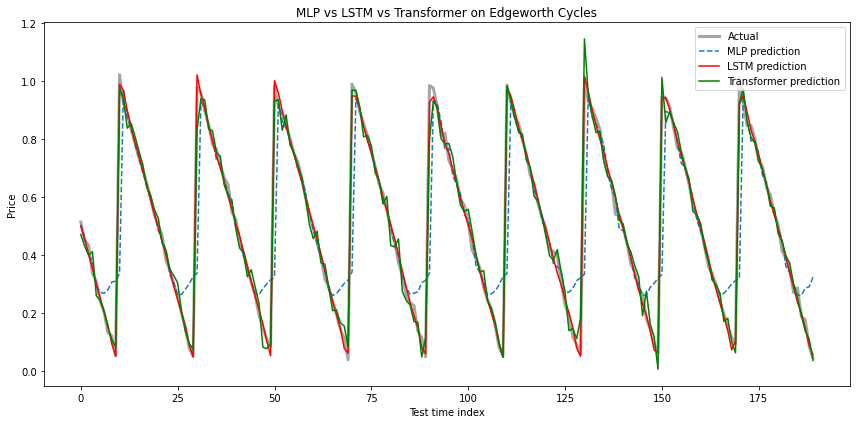

In [5]:
with torch.no_grad():
    y_mlp  = mlp (X_test_t).numpy()
    y_lstm = lstm(X_test_t).numpy()
    y_tfr  = tfr (X_test_t).numpy()

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual',                   color='black', alpha=0.35, lw=3)
plt.plot(y_mlp,  label='MLP prediction',           ls='--')
plt.plot(y_lstm, label='LSTM prediction',          color='red')
plt.plot(y_tfr,  label='Transformer prediction',   color='green')
plt.title('MLP vs LSTM vs Transformer on Edgeworth Cycles')
plt.xlabel('Test time index'); plt.ylabel('Price')
plt.legend(); plt.tight_layout(); plt.show()

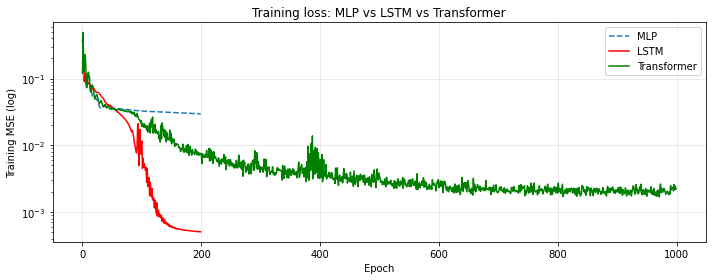

Parameter counts -- MLP: 97   LSTM: 4513   Transformer: 4657
Test RMSE        -- MLP: 0.1670   LSTM: 0.0207   Transformer: 0.0454

Reading: the MLP collapses to a constant near the cycle mean (no memory).
The LSTM tracks the sawtooth via its hidden state. The Transformer reaches
the same regime via self-attention over the window: similar parameter
budget, no recurrence, attention does the work in parallel.


In [6]:
# Training-loss curves and test RMSEs
with torch.no_grad():
    rmse_mlp  = torch.sqrt(nn.functional.mse_loss(mlp (X_test_t), y_test_t)).item()
    rmse_lstm = torch.sqrt(nn.functional.mse_loss(lstm(X_test_t), y_test_t)).item()
    rmse_tfr  = torch.sqrt(nn.functional.mse_loss(tfr (X_test_t), y_test_t)).item()

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(loss_mlp,  label='MLP',         ls='--')
ax.semilogy(loss_lstm, label='LSTM',        color='red')
ax.semilogy(loss_tfr,  label='Transformer', color='green')
ax.set_xlabel('Epoch'); ax.set_ylabel('Training MSE (log)')
ax.set_title('Training loss: MLP vs LSTM vs Transformer')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Parameter counts -- MLP: {n_params(mlp)}   LSTM: {n_params(lstm)}   Transformer: {n_params(tfr)}')
print(f'Test RMSE        -- MLP: {rmse_mlp:.4f}   LSTM: {rmse_lstm:.4f}   Transformer: {rmse_tfr:.4f}')
print()
print('Reading: the MLP collapses to a constant near the cycle mean (no memory).')
print('The LSTM tracks the sawtooth via its hidden state. The Transformer reaches')
print('the same regime via self-attention over the window: similar parameter')
print('budget, no recurrence, attention does the work in parallel.')

## 6. Discussion: why these three models behave the way they do

**MLP.** Sees only $x_t$, so it can only learn the marginal mapping $x_t \mapsto x_{t+1}$. On a sawtooth this mapping is nearly one-to-many (the same $x_t$ value occurs at very different phases of the cycle), so the network's best response is to predict near the conditional mean. This is the *no-memory baseline*.

**LSTM.** A recurrent hidden state $h_t$ accumulates information across the window. The gating mechanism is a strong inductive bias for periodic / asymmetric series like Edgeworth cycles: the cell state can encode "how far into the current cycle we are" and the gates can decide when to reset.

**Transformer.** Drops recurrence entirely.  Self-attention lets every position read every other directly, in parallel.  On a moderate-length window the model recovers the cycle from the data alone, with no recurrent inductive bias built in.  This is exactly the trade-off that motivated the architecture: more general, more parallelizable, less hard-coded structure.  On this *tiny* problem (1000 points, very regular signal) the LSTM is the right tool; on long-context, large-data tasks (language, market microstructure tick data, document-level forecasts) the Transformer's $\mathcal{O}(1)$ direct path between positions wins.

**Take-home.** Architecture choice is about matching the inductive bias of the model to the structure of the problem.  The historical sequence MLP $\to$ LSTM $\to$ Transformer corresponds to *removing* hard-coded structure and *adding* flexibility -- which is helpful when data and context grow, and overkill when neither does.

**Try yourself.**  Increase `n_points` to 10 000 and the period to 50; raise the Transformer's `num_layers` to 3 and `d_model` to 32.  You should see the Transformer pull ahead of the LSTM as the context lengthens and the data budget grows.